# Notebook 05: Transaction Costs

## Objective

Assess how trading costs influence backtest performance.

A fixed transaction cost of 0.1% is applied whenever the strategy changes position.

The cost-adjusted results are compared with the original frictionless backtest.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

sys.path.append("..")
from src.data_loader import load_data
from src.metrics import total_return,sharpe_ratio,max_drawdown

In [2]:
df=load_data("SPY")
print(df.head())

d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open    Volume
Ticker             SPY         SPY         SPY         SPY       SPY
Date                                                                
2020-01-02  296.888245  296.906540  294.749797  295.672813  59151200
2020-01-03  294.640106  295.764174  293.442942  293.497772  77709700
2020-01-06  295.764130  295.846374  292.766617  292.885424  55653900
2020-01-07  294.932556  295.672787  294.484742  295.197558  40496400
2020-01-08  296.504303  297.719734  294.877620  295.124354  68296000


In [3]:
df = load_data("SPY")

if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

df.head()

d:\Portfolio\Quant Projects\Backtesting-Bias-Analysis-main\Backtesting-Bias-Analysis-main\notebooks\..\src\data_loader.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2020-01-02,296.888184,296.906479,294.749737,295.672752,59151200
2020-01-03,294.640045,295.764112,293.442881,293.497711,77709700
2020-01-06,295.764099,295.846344,292.766587,292.885394,55653900
2020-01-07,294.932526,295.672756,294.484712,295.197527,40496400
2020-01-08,296.504333,297.719765,294.877650,295.124385,68296000


In [4]:
df["SMA_50"] = df["Close"].rolling(50).mean()
df["SMA_200"] = df["Close"].rolling(200).mean()

df["Signal"] = 0
df.loc[df["SMA_50"] > df["SMA_200"], "Signal"] = 1

df[["Close", "SMA_50", "SMA_200", "Signal"]].tail()

Price,Close,SMA_50,SMA_200,Signal
Date,,,,
2026-06-08,739.219971,715.394399,682.097073,1
2026-06-09,737.049988,717.453599,682.631301,1
2026-06-10,725.429993,719.322799,683.059039,1
2026-06-11,737.760010,721.071199,683.562508,1
2026-06-12,741.750000,722.801399,684.072590,1


In [5]:
df["Returns"] = df["Close"].pct_change()

df["Strategy_Returns"] = (
    df["Signal"].shift(1) * df["Returns"]
)

df[["Returns", "Strategy_Returns"]].head()

Price,Returns,Strategy_Returns
Date,,
2020-01-02,NaN,NaN
2020-01-03,-0.007572,-0.0
2020-01-06,0.003815,0.0
2020-01-07,-0.002812,-0.0
2020-01-08,0.005329,0.0


In [6]:
df["Trades"] = df["Signal"].diff().abs()

transaction_cost = 0.001

In [17]:
df["Strategy_Returns_TC"] = (
    df["Strategy_Returns"]
    - df["Trades"] * transaction_cost
)

In [19]:
df["Equity_TC"] = (
    1 + df["Strategy_Returns_TC"].fillna(0)
).cumprod()

In [20]:
df["Equity"] = (1 + df["Strategy_Returns"].fillna(0)).cumprod()
df["Market"] = (1 + df["Returns"].fillna(0)).cumprod()

Text(0.5, 1.0, 'Impact of Transaction Costs')

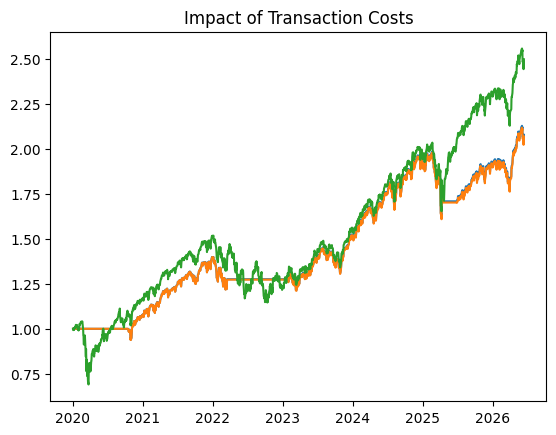

In [21]:
plt.plot(df.index,
         df["Equity"],
         label="Without Costs")

plt.plot(df.index,
         df["Equity_TC"],
         label="With Costs")

plt.plot(df.index,
         df["Market"],
         label="Buy & Hold")
plt.title("Impact of Transaction Costs")

In [15]:
returns = df["Strategy_Returns"].dropna()

print("Total Return:",
      round(total_return(df["Equity"])*100,2), "%")

print("Sharpe Ratio:",
      round(sharpe_ratio(returns),2))

print("Max Drawdown:",
      round(max_drawdown(df["Equity"])*100,2), "%")

Total Return: 107.86 %
Sharpe Ratio: 0.96
Max Drawdown: -18.76 %


In [16]:
returns_tc = df["Strategy_Returns_TC"].dropna()

print("\nWITH TRANSACTION COSTS")

print("Total Return:",
      round(total_return(df["Equity_TC"])*100,2), "%")

print("Sharpe Ratio:",
      round(sharpe_ratio(returns_tc),2))

print("Max Drawdown:",
      round(max_drawdown(df["Equity_TC"])*100,2), "%")


WITH TRANSACTION COSTS
Total Return: 106.82 %
Sharpe Ratio: 0.95
Max Drawdown: -18.76 %


## Interpretation

The inclusion of transaction costs reduced strategy profitability.

Although the SMA crossover strategy trades infrequently, repeated costs still accumulate over time.

Ignoring these frictions can overstate the attractiveness of a strategy, particularly for higher-turnover systems.